# Test for code to transtion between lower tropospheric entrainment (dpmdz) and upper tropospheric entrainment (dmpdz_ut)
## This is controled by 2 pressure levels and dmpz transtions from dmpdz to dmpdz_ut between them.

In [3]:
import numpy as np
import matplotlib.pyplot as mp
import xarray as xr
import pandas as pd
import glob
import seaborn as sbn


print(xr.__version__)

2025.6.1


In [13]:
# PLOT LINES OF VARYING DMPDZ


cases = ['CAM3-','CAM4+','5b','6b','7b','9b','10b','11b']

dmpdz =        [0.,     1e-3,  1e-3,  2.e-3,  2.e-3, 3.e-3, 1.e-4, 1.e-3]
dmpdz_ut =     [0.,     1e-3,  1e-4,  1.e-4,  1.e-4, 1e-4, 1.e-4, 1.e-4]

dmpdz_ltzlev = [1000.,  1000,  1000,  1000.,  3000,  3000, 1000, 1000]
dmpdz_utzlev = [5000.,  5000,  5000,  5000.,  5000,  5000, 3000, 3000]

ztop = 10000
zbot = 0
num_values = 100  # Number of values in the array

zht = np.linspace(zbot, ztop, num_values)

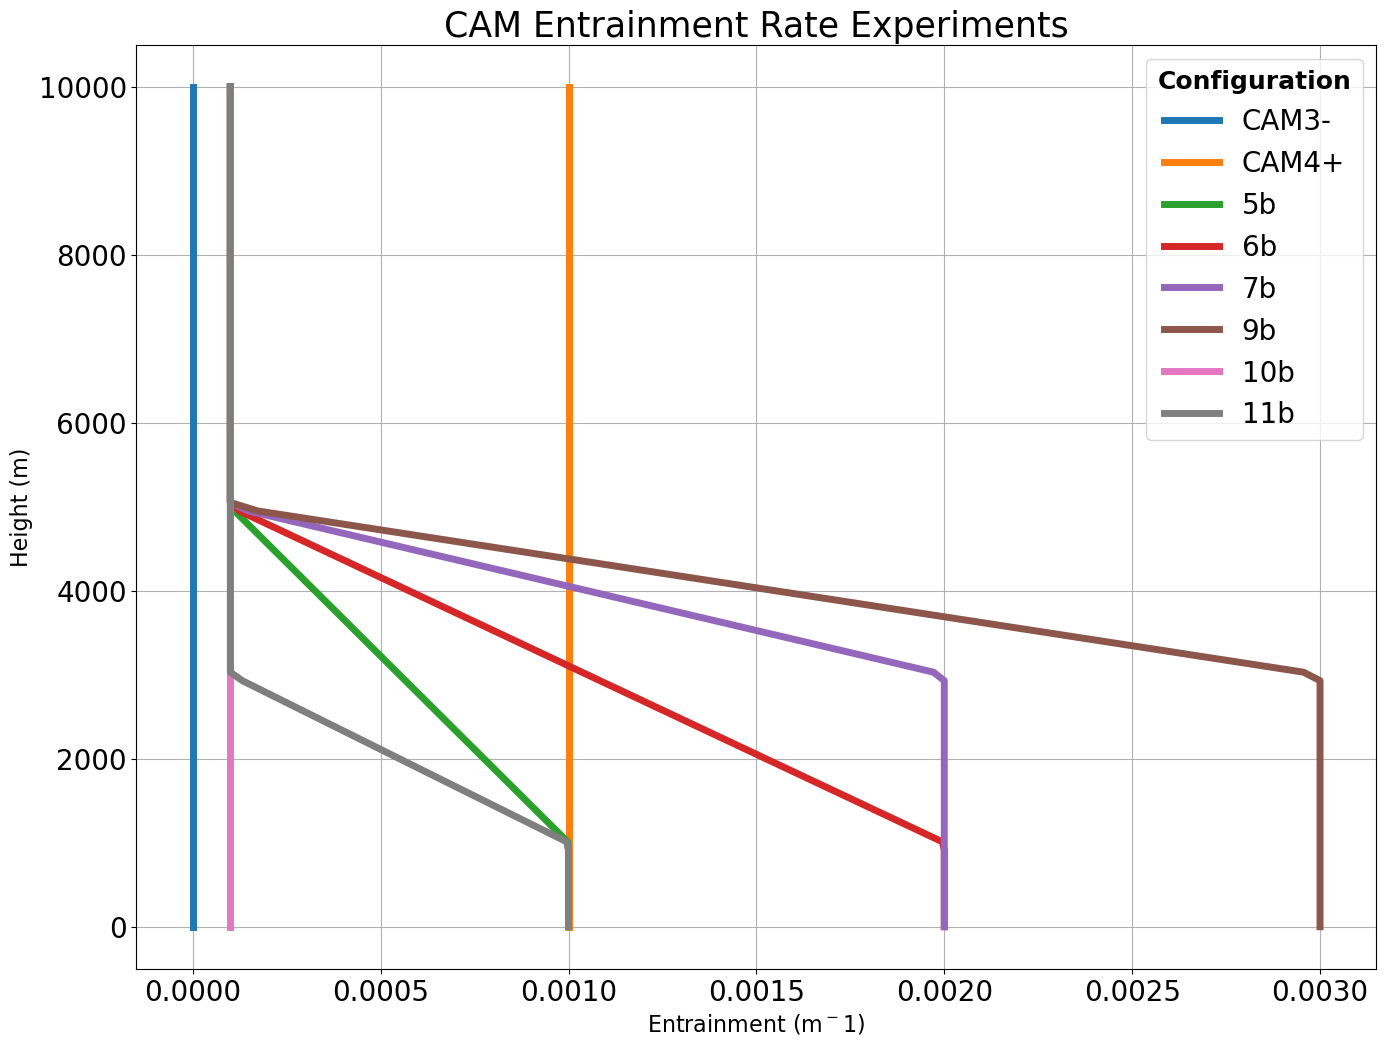

In [14]:
plt1, ax1 = mp.subplots(1,1,figsize=(16, 12)) # Ave plot of all cases

mp.rcdefaults()
mp.rcParams.update({'font.size': 18})


mp.rcParams.update({
    'axes.titlesize': 25,
    'axes.labelsize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
})


dmpdz_p = np.empty_like(zht)
offset = 0.

for ic,case in enumerate(cases):
    for iz,zz in enumerate(zht):
    

        zz_i = max(dmpdz_ltzlev[ic],min(zz,dmpdz_utzlev[ic]))
        z_transition = (dmpdz_ltzlev[ic]-zz_i)/(dmpdz_ltzlev[ic]-dmpdz_utzlev[ic])
        dmpdz_p[iz] =  dmpdz_ut[ic]*z_transition + dmpdz[ic]*(1-z_transition)
        dmpdz_p[iz] = dmpdz_p[iz]+ic*offset

    ax1.plot(dmpdz_p,zht,label=cases[ic],lw=5)

ax1.set_title('CAM Entrainment Rate Experiments') 
ax1.set_xlabel('Entrainment (m$^-1$)') 
ax1.set_ylabel('Height (m)') 
ax1.grid(True) 


legend = ax1.legend(title='Configuration',fontsize=20)
legend_labels = legend.get_texts()
legend.get_title().set_fontweight('bold') 


#print (iz, zz, zz_i,dmpdz_p,z_transition)
dir_fig = '/glade/u/home/rneale/python/python-figs/zm_dev/'
plt1.savefig(dir_fig+'CAM7_dmpdz_sensitivity_experiments.png')



CASE =  CAM3-


NameError: name 'fdir_s' is not defined

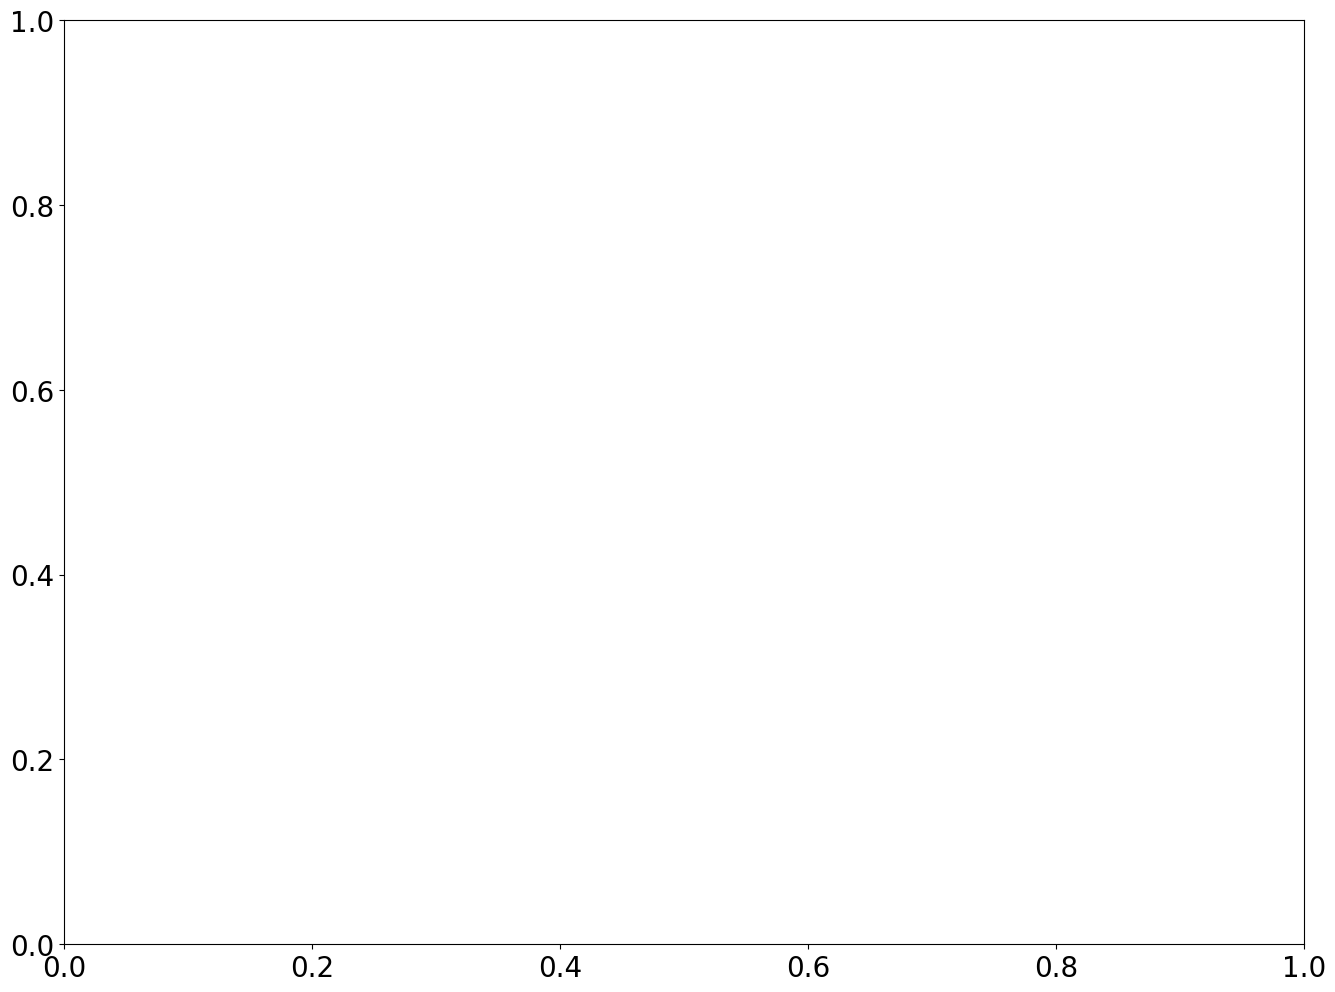

In [15]:
plt1, ax1 = mp.subplots(1,1,figsize=(16, 12)) # Ave plot of all cases
#sbn.color_palette("colorblind")
#colors = ['olive','coral','purple']
colors = ['blue','red','purple']

for ic,case in enumerate(cases):

    
    print()
    print('CASE = ',case)
    
    if ic > 1:
        ffile0 = fdir_s+case+'/run/'+case
    else:
        ffile0 = fdir_s+'archive/'+cases[ic]+'/atm/hist/'+case
    
    
    ffile = ffile0+'*h3i*2010*nc'
    print(ffile)
    flist  = sorted(glob.glob(ffile))
    fhist  =  xr.open_mfdataset(flist,parallel=True)  
    fhist  = fhist.sel(lat=lat_bounds, lon=lon_bounds, time=time_range)


    
    fvar = fhist[vname]
    vlong =  fvar.attrs['long_name']    
    fvar = vscale*fvar

    fprecc = fhist['PRECC']
    fprecc = vpscale*fprecc
    
    # Mask
    fvar = fvar.where(fprecc > 1.)
    
    # 1d-ize
    pvar_1d = fvar.values.ravel()
    print(pvar_1d[0:100])
        
    # PDF
    
    sbn.histplot(pvar_1d, binwidth=bwidth, binrange=(40, 1000),color=colors[ic],linewidth=1,multiple="layer",kde=True, fill=False,stat="probability", ) 

    del pvar_1d

leg = ax1.legend(cnames,loc='upper left',fontsize=40)

#ylims = [0.,5000]

ax1.set_xlim(xlims)
#ax1.set_ylim(ylims)
#plt1.gca().invert_yaxis()
ax1.set_title('3 hourly - '+vlong,fontsize=24)
ax1.set_ylabel('Relative frequency',fontsize=29) 
ax1.set_xlabel('Pressure (mb)',fontsize=29)
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
#ax1.vlines(0.,ylims[0] ,ylims[1], color='black',linestyle="dashed",lw=1)

for line in leg.get_lines():
    line.set_linewidth(4.0)

plt1.savefig('pdf_vres_'+vname+'_Jul.png', dpi=100, bbox_inches='tight') 

NameError: name 'pdf_data_proc' is not defined

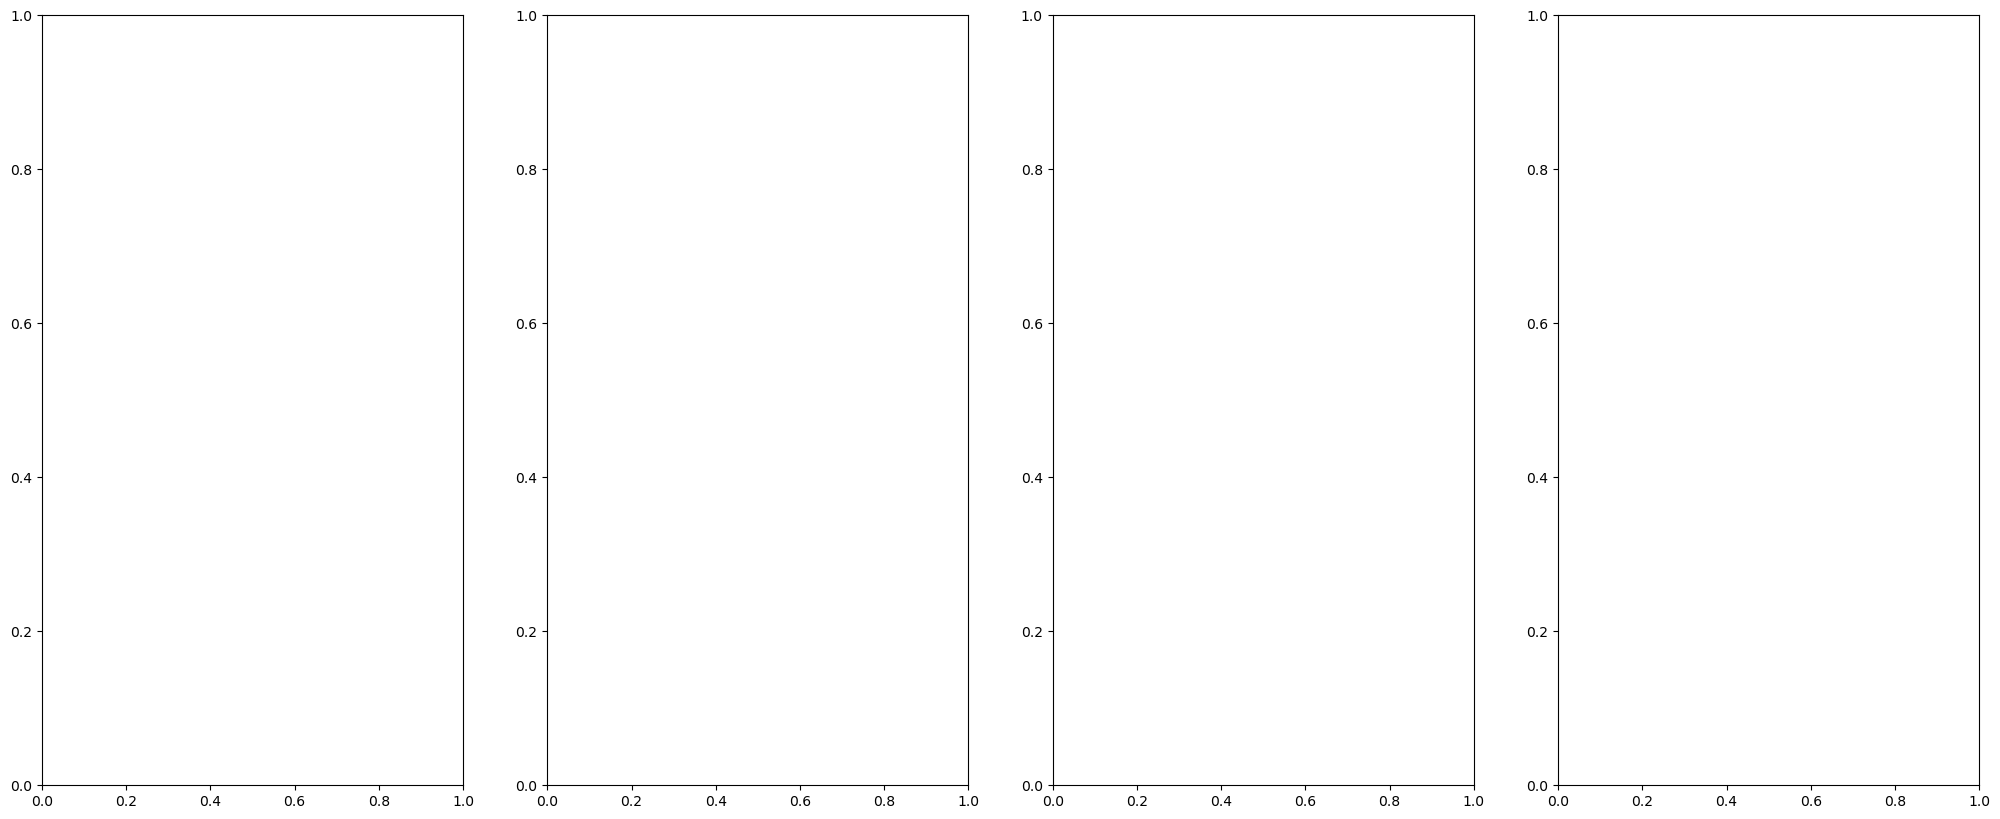

In [41]:
### 2D histogram ###

plt2, ax2 = mp.subplots(1,4,figsize=(25, 10)) # Ave plot of all cases

colors = ['black','skyblue','olive','coral']

for ic,case in enumerate(cases):

    fplot,vlong = pdf_data_proc(case,fdir0,vname,vscale) # Main variable
    fplotc,vlongc = pdf_data_proc(case,fdir0,vnamec,vscalec) # Always grab CONVECTIVE VARIABLE.
   
    

    ax2[ic].scatter(fplotc, fplot,color=colors[ic],alpha=0.1,marker='.',s=1)
    
#    ax2[ic].hist2d(fplotc, fplot, bins=(50, 50),range=([-50,10],[-20,50]))
    
    ax2[ic].vlines(0.,-60, 80, color='black',linestyle="dashed",lw=1)
    ax2[ic].hlines(0.,-60, 10, color='black',linestyle="dashed",lw=1)
    
    ax2[ic].set_title(cnames[ic],fontsize=24)
    ax2[ic].set_ylabel(vlong,fontsize=20) 
    ax2[ic].set_xlabel(vlongc,fontsize=15)
    ax2[ic].tick_params(axis='x', labelsize=16)
    ax2[ic].tick_params(axis='y', labelsize=16)
    
plt2.savefig('pdf_vres_scatter.png', dpi=100, bbox_inches='tight') 